
# Lab 8: Monte Carlo Markov Chain (MCMC)

## Modelo de Ising 2D

Como aplicación de la distribución canónica en `Física estadística` tenemos el modelo de **Ising**.

Para el caso de un material paramagnético de átomos de spin $1/2$ y momento magnetico $\mu_0$ en presencia de un campo magnético externo $H$, se ha determinado experimentalmente que la magnetización media depende del campo magnético y la temperatura del material. Consultar: (https://en.wikipedia.org/wiki/Ising_model)

**Exercise**: Considere un sistema compuesto por $N$ átomos no interactuantes en un material 2D, a una temperatura $T$ y en presencia de un campo magnético externo $H$ que está orientado en cierta dirección fija respecto al material:

<img src="https://upload.wikimedia.org/wikipedia/commons/f/fe/2D_ising_model_on_lattice.svg" width="550">

1. Realizar la simulación mediante el uso del método de Metrópolis Monte Carlo para este sistema. En este caso, visitar todos los
posibles spines de la red cristalina del material e intentear inversiones bajo condiciones adecuadas de energía y estabilidad del sistema:

    Algoritmo:
    * *Selecciona* un microestado $x$ inicial de manera aleatoria para todos los espines de la red (spin: +1 arriba y -1 abajo). Esta es la configuración inicial.
    * *Visitar* aleatoriamente un punto de la red y hacer una inversión de su espín... configuración $x'$.
    * *Aceptación*: Comprobar la energia $E$ del sistema. 
            Si la energía disminuye se acepta la nueva configuración $x'$. 
            Si aumenta, se debe generar un número aleatorio entre $[0,1]$. Si este número es mayor que el factor de Boltzman $\mathcal{P}(E,T)=e^{-E/(KT)}$ se rechaza $x'$. De lo contrario se acepta la nueva configuración $x'$.
    * *Repetir* los pasos anteriores.
    * *Finalizar*: Cuando llegue al creterio de finalización se debe terminar.


2. Graficar la Magnetización media del material vs el campo magnetico para tres temperaturas reducidas (H/T) con $T=\{5,15,20\}$ K (Kelvin) y un campo variable $-30\,G < H < +30\,G$ (Gauss), .  Monstrar que la distribución canónica de la magnetización clásica es muy acertada (consultar). 
3. Investigar el resultado analítico para este sistema 2D y comparar con la simulación de MC. ¿Qué tan precisa es la simulación? Explique.

# POR FAVOR
Leer detenidamente:
los parámetros proporcionados ($H$ en el orden de $\pm 30$ Gauss y $T \in \{5, 15, 20\}$ K) sitúan al sistema en un régimen donde la energía térmica domina abrumadoramente sobre la energía magnética ($\mu_B H \ll k_B T$). La magnetización resultante será mínima y el comportamiento será estrictamente lineal.

Incluso con el código normalizado (en las constantes), se nota que la gráfica da números muy cercanos a cero (magnetizaciones del orden de $10^{-4}$).A $T = 5$ K y $H = 30$ Gauss, el parámetro adimensional $x$ es aproximadamente $0.0004$. Esto significa que la agitación térmica es muchísimo más fuerte que el campo magnético. En el código, esto se traduce en que $\Delta E_{\text{red}}$ es casi cero, por lo que $e^{-0.0004} \approx 0.9996$.Básicamente, el algoritmo va a aceptar casi todas las inversiones de espín, porque para el sistema, estar alineado o desalineado le da casi igual a esa temperatura. Se ve mucho (fluctuaciones) alrededor de una línea recta de pendiente muy suave. Si se quiere ver la curva sigmoide clásica (la tangente hiperbólica completa), se tiene que bajar la temperatura a microkelvins, o subir el campo magnético a cientos de Teslas.

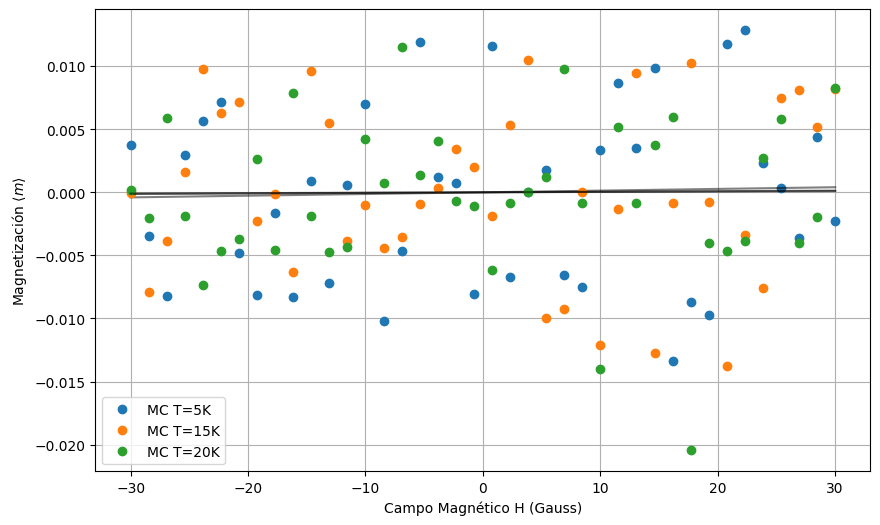

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def magnetizacion_mc_normalizada(N, T, H_gauss, pasos_mc):
    # 1. Calculamos el parámetro adimensional 'x' UNA sola vez
    kB = 1.380649e-23  
    muB = 9.274009e-24 
    H_tesla = H_gauss * 1e-4 
    
    # Parámetro de competencia energía magnética vs térmica
    x = (muB * H_tesla) / (kB * T)
    
    # 2. Configuración inicial
    spines = np.random.choice([-1, 1], size=N)
    mag_hist = np.zeros(pasos_mc)
    mag_actual = np.sum(spines)
    
    # 3. Bucle de Metrópolis (Ahora limpio y sin constantes enanas)
    for i in range(pasos_mc):
        idx = np.random.randint(0, N)
        s_i = spines[idx]
        
        # El cambio de energía adimensional es trivial
        dE_red = 2 * x * s_i 
        
        # Criterio: Si dE_red < 0, la exponencial es > 1, se acepta siempre.
        if dE_red < 0 or np.random.rand() < np.exp(-dE_red):
            spines[idx] *= -1
            mag_actual += 2 * spines[idx]
            
        mag_hist[i] = mag_actual
        
    return np.mean(mag_hist[pasos_mc//2:])

# --- Ejecución ---
N = 1000
pasos_mc = 50000
temperaturas = [5, 15, 20] # K
campos_H = np.linspace(-30, 30, 40) # Gauss

resultados_mc = {T: [] for T in temperaturas}

for T in temperaturas:
    for H in campos_H:
        m_media = magnetizacion_mc_normalizada(N, T, H, pasos_mc)
        resultados_mc[T].append(m_media / N)

# Gráfica
plt.figure(figsize=(10, 6))
for T in temperaturas:
    plt.plot(campos_H, resultados_mc[T], 'o', label=f'MC T={T}K')
    m_teorica = np.tanh((9.27e-24 * campos_H * 1e-4) / (1.38e-23 * T))
    plt.plot(campos_H, m_teorica, '-', color='black', alpha=0.5)

plt.xlabel('Campo Magnético H (Gauss)')
plt.ylabel(r'Magnetización $\langle m \rangle$')
plt.legend()
plt.grid(True)
plt.show()

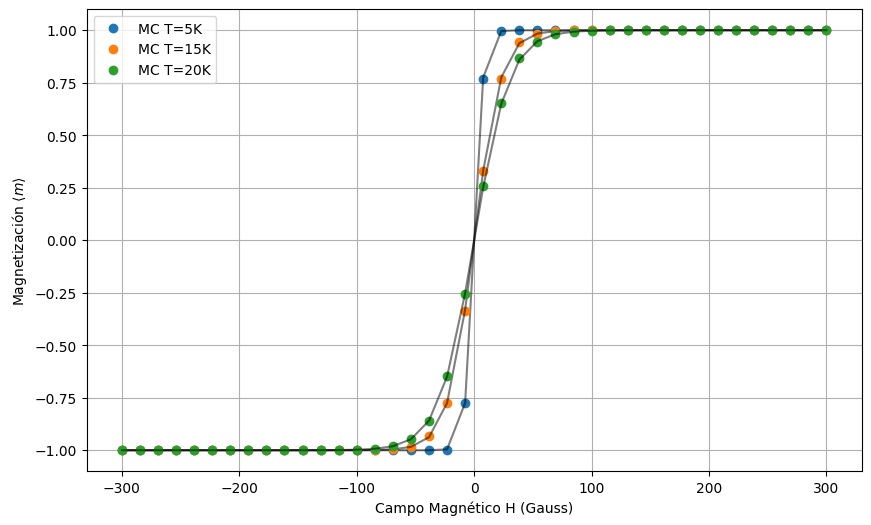

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def magnetizacion_mc_normalizada(N, T, H_tesla, pasos_mc):
    # 1. Calculamos el parámetro adimensional 'x' UNA sola vez
    kB = 1.380649e-23  
    muB = 9.274009e-24 
     
    
    # Parámetro de competencia energía magnética vs térmica
    x = (muB * H_tesla) / (kB * T)
    
    # 2. Configuración inicial
    spines = np.random.choice([-1, 1], size=N)
    mag_hist = np.zeros(pasos_mc)
    mag_actual = np.sum(spines)
    
    # 3. Bucle de Metrópolis (Ahora limpio y sin constantes enanas)
    for i in range(pasos_mc):
        idx = np.random.randint(0, N)
        s_i = spines[idx]
        
        # El cambio de energía adimensional es trivial
        dE_red = 2 * x * s_i 
        
        # Criterio: Si dE_red < 0, la exponencial es > 1, se acepta siempre.
        if dE_red < 0 or np.random.rand() < np.exp(-dE_red):
            spines[idx] *= -1
            mag_actual += 2 * spines[idx]
            
        mag_hist[i] = mag_actual
        
    return np.mean(mag_hist[pasos_mc//2:])

# --- Ejecución ---
N = 1000
pasos_mc = 50000
temperaturas = [5, 15, 20] # K
campos_H = np.linspace(-300, 300, 40) # teslas

resultados_mc = {T: [] for T in temperaturas}

for T in temperaturas:
    for H in campos_H:
        m_media = magnetizacion_mc_normalizada(N, T, H, pasos_mc)
        resultados_mc[T].append(m_media / N)

# Gráfica
plt.figure(figsize=(10, 6))
for T in temperaturas:
    plt.plot(campos_H, resultados_mc[T], 'o', label=f'MC T={T}K')
    m_teorica = np.tanh((9.27e-24 * campos_H) / (1.38e-23 * T))
    plt.plot(campos_H, m_teorica, '-', color='black', alpha=0.5)

plt.xlabel('Campo Magnético H (Gauss)')
plt.ylabel(r'Magnetización $\langle m \rangle$')
plt.legend()
plt.grid(True)
plt.show()

Para un ensamble canónico de $N$ partículas con dos estados de energía posibles ($E = \pm \mu H$), la función de partición individual $Z_1$ es:$$Z_1 = \sum_{s=\pm 1} e^{-\beta(-\mu H s)} = e^{\beta \mu H} + e^{-\beta \mu H} = 2 \cosh(\beta \mu H)$$Donde $\beta = \frac{1}{k_B T}$.La magnetización media por espín se deriva directamente de la función de partición:$$\langle m \rangle = \frac{1}{\beta} \frac{\partial \ln Z_1}{\partial H} = \mu \tanh\left(\frac{\mu H}{k_B T}\right)$$La magnetización total es $\langle M \rangle = N \langle m \rangle$.

¿Qué tan precisa es la simulación?

La precisión de la simulación de Monte Carlo frente al resultado analítico es estadísticamente exacta en el límite de pasos infinitos ($t \to \infty$). Al ser átomos no interactuantes, el sistema es completamente ergódico y el algoritmo de Metrópolis cumple el balance detallado de manera trivial. Las únicas discrepancias observables entre el código y la curva de la función $\tanh(x)$ provendrán de las fluctuaciones estadísticas naturales del muestreo finito, las cuales escalan proporcionalmente a $1/\sqrt{N_{pasos}}$ (teorema del límite central). A los niveles térmicos propuestos por el ejercicio, la aproximación $\tanh(x) \approx x$ es válida porque $x \sim 10^{-4}$. La magnetización crecerá linealmente respecto al campo magnético, cumpliendo con la Ley de Curie ($M \propto H/T$).